# 📘 Aula 2 — Tecnologias e Ferramentas para PLN
### Curso de Processamento de Linguagem Natural

---

## 🎯 Objetivos desta aula

Ao final desta aula, você será capaz de:

- Usar o **NLTK** para tokenização, remoção de stopwords e stemming
- Criar **pipelines completos de PLN** com o spaCy
- Acessar modelos e datasets do **Hugging Face**
- Manipular imagens com **OpenCV** para tarefas de PLN multimodal
- Criar e treinar modelos simples com **TensorFlow/Keras**
- Entender quando usar cada ferramenta

---

## 📚 Embasamento Teórico

### 2.1 — Por que precisamos de ferramentas especializadas?

Na Aula 1 aprendemos a representar o significado das palavras.  
Agora vamos aprender a **processar texto em escala** usando ferramentas profissionais.

Processar texto bruto exige várias etapas encadeadas — o que chamamos de **pipeline de PLN**:

```
Texto bruto
    ↓
Tokenização        → dividir o texto em palavras/frases
    ↓
Normalização       → lowercase, remoção de pontuação
    ↓
Remoção Stopwords  → eliminar palavras sem significado ("o", "a", "de")
    ↓
Stemming/Lematização → reduzir palavras à raiz ("correndo" → "correr")
    ↓
POS Tagging        → classificar palavras (substantivo, verbo, adjetivo...)
    ↓
NER                → identificar entidades (pessoas, lugares, organizações)
    ↓
Representação      → vetores numéricos para modelos de ML
```

---

### 2.2 — Visão Geral das Ferramentas

| Ferramenta | Foco | Melhor para |
|---|---|---|
| **NLTK** | Pesquisa e didática | Aprender fundamentos, corpora linguísticos |
| **spaCy** | Produção industrial | Pipelines rápidos e robustos |
| **Hugging Face** | Modelos modernos | BERT, GPT, modelos pré-treinados |
| **OpenCV** | Visão computacional | PLN multimodal, OCR, imagens |
| **TensorFlow** | Deep learning | Treinar redes neurais para PLN |

---

## ⚙️ Configuração Inicial

In [1]:
# ─────────────────────────────────────────────────────────────
# IMPORTAÇÕES E DOWNLOADS INICIAIS
# Execute esta célula antes de qualquer outra
# ─────────────────────────────────────────────────────────────

import nltk
import spacy
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

# Downloads NLTK necessários para esta aula
recursos = [
    'punkt',           # Tokenizador de sentenças e palavras
    'stopwords',       # Lista de stopwords em vários idiomas
    'rslp',            # Stemmer para Português
    'averaged_perceptron_tagger',  # POS Tagger
    'maxent_ne_chunker',           # Reconhecedor de entidades
    'words',           # Corpus de palavras
    'floresta',        # Corpus em Português
    'mac_morpho',      # Corpus morfológico em PT
    'punkt_tab',       # Tokenizador atualizado
]
for r in recursos:
    nltk.download(r, quiet=True)

print('✅ Bibliotecas carregadas!')
print(f'   NLTK    : {nltk.__version__}')
print(f'   spaCy   : {spacy.__version__}')
print(f'   OpenCV  : {cv2.__version__}')
print(f'   NumPy   : {np.__version__}')

✅ Bibliotecas carregadas!
   NLTK    : 3.8.1
   spaCy   : 3.7.4
   OpenCV  : 4.9.0
   NumPy   : 1.26.4


---
# 🔵 PARTE 1 — NLTK
## Natural Language Toolkit

O **NLTK** (Natural Language Toolkit) é a biblioteca de PLN mais antiga e didática do Python,  
criada pela Universidade da Pensilvânia em 2001. É ideal para aprender os fundamentos.

---
### 📖 Exemplo 1.1 — Tokenização

In [2]:
# ─────────────────────────────────────────────────────────────
# TOKENIZAÇÃO — dividir texto em unidades menores
#
# word_tokenize()  → divide em palavras e pontuação
# sent_tokenize()  → divide em sentenças
# ─────────────────────────────────────────────────────────────

from nltk.tokenize import word_tokenize, sent_tokenize

# Texto de exemplo em Português
texto = """O Processamento de Linguagem Natural é uma área fascinante da Inteligência Artificial.
Ele permite que computadores entendam e gerem texto humano.
Ferramentas como NLTK e spaCy tornaram o PLN acessível a todos os desenvolvedores!"""

print('📄 TEXTO ORIGINAL:')
print(texto)
print()

# ── Tokenização por sentenças
sentencas = sent_tokenize(texto, language='portuguese')
print(f'📝 Tokenização por sentenças ({len(sentencas)} sentenças):')
for i, s in enumerate(sentencas):
    print(f'  [{i+1}] {s}')

print()

# ── Tokenização por palavras (primeira sentença)
palavras = word_tokenize(sentencas[0], language='portuguese')
print(f'🔤 Tokenização por palavras ({len(palavras)} tokens):')
print(f'  {palavras}')

📄 TEXTO ORIGINAL:
O Processamento de Linguagem Natural é uma área fascinante da Inteligência Artificial.
Ele permite que computadores entendam e gerem texto humano.
Ferramentas como NLTK e spaCy tornaram o PLN acessível a todos os desenvolvedores!

📝 Tokenização por sentenças (3 sentenças):
  [1] O Processamento de Linguagem Natural é uma área fascinante da Inteligência Artificial.
  [2] Ele permite que computadores entendam e gerem texto humano.
  [3] Ferramentas como NLTK e spaCy tornaram o PLN acessível a todos os desenvolvedores!

🔤 Tokenização por palavras (13 tokens):
  ['O', 'Processamento', 'de', 'Linguagem', 'Natural', 'é', 'uma', 'área', 'fascinante', 'da', 'Inteligência', 'Artificial', '.']


---
### 📖 Exemplo 1.2 — Stopwords e Filtragem

In [3]:
# ─────────────────────────────────────────────────────────────
# STOPWORDS — palavras sem valor semântico relevante
# Ex: "o", "a", "de", "que", "em" → não ajudam a entender o tema
#
# stopwords.words('portuguese') → lista de stopwords em PT
# ─────────────────────────────────────────────────────────────

from nltk.corpus import stopwords

# Carregar stopwords do Português
stop_pt = set(stopwords.words('portuguese'))

print(f'📋 Total de stopwords em Português: {len(stop_pt)}')
print(f'   Exemplos: {sorted(list(stop_pt))[:15]}')
print()

# Tokenizar e filtrar o texto
tokens_brutos = word_tokenize(texto.lower(), language='portuguese')

# Remover stopwords e pontuação em um único passo
tokens_limpos = [
    token for token in tokens_brutos
    if token.isalpha()          # Manter apenas letras (sem pontuação)
    and token not in stop_pt    # Manter apenas tokens que NÃO são stopwords
]

print(f'📊 Comparação:')
print(f'   Tokens originais : {len(tokens_brutos)}')
print(f'   Tokens após filtro: {len(tokens_limpos)}')
print(f'   Redução          : {100 - int(len(tokens_limpos)/len(tokens_brutos)*100)}%')
print()
print(f'✅ Tokens relevantes:')
print(f'   {tokens_limpos}')

📋 Total de stopwords em Português: 207
   Exemplos: ['a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de']

📊 Comparação:
   Tokens originais : 37
   Tokens após filtro: 21
   Redução          : 44%

✅ Tokens relevantes:
   ['processamento', 'linguagem', 'natural', 'área', 'fascinante', 'inteligência', 'artificial', 'permite', 'computadores', 'entendam', 'gerem', 'texto', 'humano', 'ferramentas', 'nltk', 'spacy', 'tornaram', 'pln', 'acessível', 'todos', 'desenvolvedores']


---
### 📖 Exemplo 1.3 — Stemming e Lematização

In [4]:
# ─────────────────────────────────────────────────────────────
# STEMMING — reduz palavras à sua raiz morfológica
# (pode gerar raízes que não são palavras reais)
#
# RSLPStemmer → stemmer específico para Português
# SnowballStemmer → suporta vários idiomas
# ─────────────────────────────────────────────────────────────

from nltk.stem import RSLPStemmer, SnowballStemmer

# Stemmer para Português
stemmer_pt = RSLPStemmer()
stemmer_en = SnowballStemmer('english')

# Palavras para demonstrar
palavras_pt = ['correndo', 'correu', 'correr', 'corrida', 'correção']
palavras_en = ['running', 'runner', 'runs', 'ran', 'running']

print('🇧🇷 Stemming em Português (RSLPStemmer):')
print(f'  {"Palavra":<15} {"Stem (raiz)"}')
print('  ' + '-' * 30)
for p in palavras_pt:
    stem = stemmer_pt.stem(p)
    print(f'  {p:<15} → {stem}')

print()
print('🇺🇸 Stemming em Inglês (SnowballStemmer):')
print(f'  {"Palavra":<15} {"Stem (raiz)"}')
print('  ' + '-' * 30)
for p in palavras_en:
    stem = stemmer_en.stem(p)
    print(f'  {p:<15} → {stem}')

print()
print('💡 Observação: o stemming é agressivo e pode gerar raízes não-palavras.')
print('   Para obter formas reais (lemas), use a lematização do spaCy (Exemplo 2.3).')

🇧🇷 Stemming em Português (RSLPStemmer):
  Palavra         Stem (raiz)
  ------------------------------
  correndo        → corr
  correu          → corr
  correr          → corr
  corrida         → corr
  correção        → correç

🇺🇸 Stemming em Inglês (SnowballStemmer):
  Palavra         Stem (raiz)
  ------------------------------
  running         → run
  runner          → runner
  runs            → run
  ran             → ran
  running         → run

💡 Observação: o stemming é agressivo e pode gerar raízes não-palavras.
   Para obter formas reais (lemas), use a lematização do spaCy (Exemplo 2.3).


---
### 📖 Exemplo 1.4 — Frequência de Palavras

📊 Corpus mac_morpho (amostra de 5000 tokens)
   Total de tokens únicos (sem stopwords): 1268

🏆 Top 10 palavras mais frequentes:
  #    Palavra              Frequência   Gráfico
  -------------------------------------------------------
  1    solo                 30           ██████████
  2    diz                  21           ███████
  3    milhões              17           █████
  4    erosão               17           █████
  5    desertificação       15           █████
  6    produção             13           ████
  7    segundo              13           ████
  8    terra                13           ████
  9    paulo                12           ████
  10   anos                 12           ████


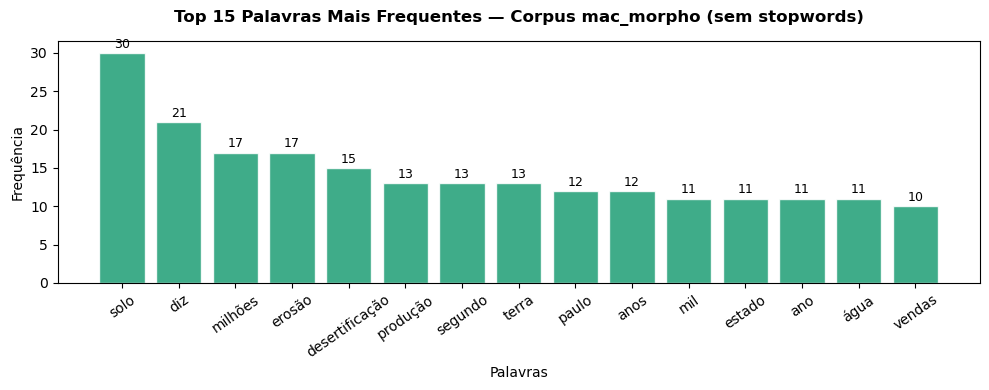

In [5]:
# ─────────────────────────────────────────────────────────────
# FREQUÊNCIA DE PALAVRAS com FreqDist
# Ferramenta útil para análise exploratória de textos
#
# FreqDist() → cria distribuição de frequência
# .most_common(n) → retorna os n tokens mais frequentes
# ─────────────────────────────────────────────────────────────

from nltk.probability import FreqDist

# Usar o corpus 'mac_morpho' em Português (já baixado)
from nltk.corpus import mac_morpho

# Obter palavras do corpus (primeiras 5000 para ser rápido)
palavras_corpus = [p.lower() for p in mac_morpho.words()[:5000]
                   if p.isalpha() and p.lower() not in stop_pt]

# Criar distribuição de frequência
freq = FreqDist(palavras_corpus)

print(f'📊 Corpus mac_morpho (amostra de 5000 tokens)')
print(f'   Total de tokens únicos (sem stopwords): {len(freq)}')
print()
print('🏆 Top 10 palavras mais frequentes:')
print(f'  {"#":<4} {"Palavra":<20} {"Frequência":<12} {"Gráfico"}')
print('  ' + '-' * 55)
for i, (palavra, contagem) in enumerate(freq.most_common(10)):
    barra = '█' * int(contagem / 3)
    print(f'  {i+1:<4} {palavra:<20} {contagem:<12} {barra}')

# Plotar gráfico de frequência
fig, ax = plt.subplots(figsize=(10, 4))
top_palavras = freq.most_common(15)
termos = [t[0] for t in top_palavras]
counts = [t[1] for t in top_palavras]
bars = ax.bar(termos, counts, color='#1D9E75', alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Palavras Mais Frequentes — Corpus mac_morpho (sem stopwords)',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Palavras', fontsize=10)
ax.set_ylabel('Frequência', fontsize=10)
ax.tick_params(axis='x', rotation=35)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
# 🟢 PARTE 2 — spaCy
## Pipeline Industrial de PLN

O **spaCy** é uma biblioteca de PLN para produção — rápida, precisa e com suporte  
a mais de 70 idiomas. Ao contrário do NLTK (didático), o spaCy foi projetado para  
ser usado em aplicações reais.

---
### 📖 Exemplo 2.1 — Carregando o Pipeline

In [6]:
# ─────────────────────────────────────────────────────────────
# PIPELINE spaCy
# Um pipeline é uma sequência de componentes que processam
# o texto de forma encadeada automaticamente
#
# spacy.load('modelo') → carrega um modelo de linguagem
# nlp(texto)           → processa o texto pelo pipeline completo
# ─────────────────────────────────────────────────────────────

# Carregar modelos — PT e EN
nlp_pt = spacy.load('pt_core_news_sm')  # Modelo em Português
nlp_en = spacy.load('en_core_web_sm')   # Modelo em Inglês

print('✅ Modelos carregados!')
print()

# Ver os componentes do pipeline
print('🔧 Componentes do pipeline (Português):')
for nome, componente in nlp_pt.pipeline:
    print(f'   → {nome:<20} {type(componente).__name__}')

print()

# Processar um texto simples
texto_pt = "Pedro Álvares Cabral chegou ao Brasil em 1500 com uma frota de 13 navios."
doc = nlp_pt(texto_pt)

print(f'📄 Texto processado: "{texto_pt}"')
print(f'   Tokens : {len(doc)}')
print(f'   Sentenças: {len(list(doc.sents))}')

✅ Modelos carregados!

🔧 Componentes do pipeline (Português):
   → tok2vec              Tok2Vec
   → morphologizer        Morphologizer
   → parser               DependencyParser
   → lemmatizer           EditTreeLemmatizer
   → attribute_ruler      AttributeRuler
   → ner                  EntityRecognizer

📄 Texto processado: "Pedro Álvares Cabral chegou ao Brasil em 1500 com uma frota de 13 navios."
   Tokens : 15
   Sentenças: 1


---
### 📖 Exemplo 2.2 — POS Tagging (Classificação Gramatical)

In [7]:
# ─────────────────────────────────────────────────────────────
# POS TAGGING — Part-of-Speech Tagging
# Classifica cada token com sua categoria gramatical
#
# token.pos_  → categoria (NOUN, VERB, ADJ...)
# token.tag_  → tag detalhada
# token.dep_  → relação de dependência sintática
# ─────────────────────────────────────────────────────────────

# Mapeamento de categorias para Português
pos_map = {
    'NOUN': 'Substantivo', 'VERB': 'Verbo',    'ADJ': 'Adjetivo',
    'ADV':  'Advérbio',    'PRON': 'Pronome',  'DET': 'Artigo/Det.',
    'ADP':  'Preposição',  'CONJ': 'Conjunção','PROPN': 'Nome Próprio',
    'NUM':  'Numeral',     'PUNCT': 'Pontuação','CCONJ': 'Conj. Coord.',
    'AUX':  'Auxiliar',   'SCONJ': 'Conj. Sub.'
}

frase = "A inteligência artificial está transformando a sociedade moderna rapidamente."
doc = nlp_pt(frase)

print(f'📝 Frase: "{frase}"')
print()
print(f'  {"Token":<22} {"POS":<12} {"Categoria (PT)":<20} {"Dependência"}')
print('  ' + '-' * 68)

for token in doc:
    categoria = pos_map.get(token.pos_, token.pos_)
    print(f'  {token.text:<22} {token.pos_:<12} {categoria:<20} {token.dep_}')

print()
# Contar por categoria
from collections import Counter
contagem = Counter([pos_map.get(t.pos_, t.pos_) for t in doc if t.pos_ != 'PUNCT'])
print('📊 Distribuição de categorias:')
for cat, n in contagem.most_common():
    print(f'   {cat:<20} {n}')

📝 Frase: "A inteligência artificial está transformando a sociedade moderna rapidamente."

  Token                  POS          Categoria (PT)       Dependência
  --------------------------------------------------------------------
  A                      DET          Artigo/Det.          det
  inteligência           NOUN         Substantivo          nsubj
  artificial             ADJ          Adjetivo             amod
  está                   AUX          Auxiliar             aux
  transformando          VERB         Verbo                ROOT
  a                      DET          Artigo/Det.          det
  sociedade              NOUN         Substantivo          obj
  moderna                ADJ          Adjetivo             amod
  rapidamente            ADV          Advérbio             amod
  .                      PUNCT        Pontuação            punct

📊 Distribuição de categorias:
   Artigo/Det.          2
   Substantivo          2
   Adjetivo             2
   Auxiliar          

---
### 📖 Exemplo 2.3 — Lematização e Similaridade

In [8]:
# ─────────────────────────────────────────────────────────────
# LEMATIZAÇÃO — reduz palavras à forma canônica (lema)
# Diferente do stemming: o lema SEMPRE é uma palavra real
#
# token.lemma_  → lema do token
# token.is_stop → True se for stopword
# ─────────────────────────────────────────────────────────────

texto_lema = "Os cientistas estavam desenvolvendo algoritmos inovadores para processar textos."
doc_lema = nlp_pt(texto_lema)

print('🔄 Comparação: Stemming (NLTK) × Lematização (spaCy)\n')
print(f'  {"Token Original":<22} {"Lema (spaCy)":<22} {"Stopword?"}')
print('  ' + '-' * 55)

for token in doc_lema:
    if not token.is_punct:  # Ignorar pontuação
        stop = '✅ sim' if token.is_stop else '  não'
        print(f'  {token.text:<22} {token.lemma_:<22} {stop}')

print()

# ── Similaridade entre documentos com spaCy
print('📏 Similaridade entre sentenças (vetores de palavras):\n')

frases = [
    "Gosto muito de cachorros.",
    "Adoro animais de estimação.",
    "O carro é rápido."
]

docs = [nlp_pt(f) for f in frases]

print(f'  Frase base: "{frases[0]}"\n')
for i in range(1, len(docs)):
    sim = docs[0].similarity(docs[i])
    barra = '█' * int(sim * 20)
    print(f'  × "{frases[i]}"')
    print(f'    Similaridade: {sim:.4f}  {barra}\n')

🔄 Comparação: Stemming (NLTK) × Lematização (spaCy)

  Token Original         Lema (spaCy)           Stopword?
  -------------------------------------------------------
  Os                     o                      ✅ sim
  cientistas             cientista                não
  estavam                estar                    não
  desenvolvendo          desenvolver              não
  algoritmos             algoritmos               não
  inovadores             inovador                 não
  para                   para                   ✅ sim
  processar              processar                não
  textos                 texto                    não

📏 Similaridade entre sentenças (vetores de palavras):

  Frase base: "Gosto muito de cachorros."

  × "Adoro animais de estimação."
    Similaridade: 0.6214  ████████████

  × "O carro é rápido."
    Similaridade: 0.3799  ███████



---
### 📖 Exemplo 2.4 — NER (Reconhecimento de Entidades Nomeadas)

In [9]:
# ─────────────────────────────────────────────────────────────
# NER — Named Entity Recognition
# Identifica automaticamente entidades no texto:
# pessoas, organizações, locais, datas, valores monetários...
#
# doc.ents      → todas as entidades encontradas
# ent.text      → texto da entidade
# ent.label_    → tipo da entidade (PER, ORG, LOC, DATE...)
# ─────────────────────────────────────────────────────────────

# Mapa de tipos de entidade
ner_map = {
    'PER': '👤 Pessoa',     'ORG': '🏢 Organização',
    'LOC': '📍 Local',      'DATE': '📅 Data',
    'MONEY': '💰 Valor',    'GPE': '🌍 País/Cidade',
    'MISC': '❓ Misc',      'TIME': '⏰ Tempo'
}

texto_ner = (
    "Elon Musk fundou a SpaceX em 2002 em Hawthorne, Califórnia. "
    "Em 2023, a empresa realizou mais de 90 lançamentos. "
    "A NASA investiu 3 bilhões de dólares em contratos com a SpaceX."
)

doc_ner = nlp_en(texto_ner)  # Usando modelo EN (melhor NER)

print(f'📄 Texto:\n   "{texto_ner}"')
print()
print('🏷️ Entidades encontradas:')
print(f'  {"Entidade":<25} {"Tipo":<10} {"Descrição"}')
print('  ' + '-' * 55)

entidades_unicas = set()
for ent in doc_ner.ents:
    chave = (ent.text, ent.label_)
    if chave not in entidades_unicas:
        descricao = ner_map.get(ent.label_, ent.label_)
        print(f'  {ent.text:<25} {ent.label_:<10} {descricao}')
        entidades_unicas.add(chave)

print()
print(f'   Total de entidades únicas: {len(entidades_unicas)}')

📄 Texto:
   "Elon Musk fundou a SpaceX em 2002 em Hawthorne, Califórnia. Em 2023, a empresa realizou mais de 90 lançamentos. A NASA investiu 3 bilhões de dólares em contratos com a SpaceX."

🏷️ Entidades encontradas:
  Entidade                  Tipo       Descrição
  -------------------------------------------------------
  Elon Musk                 PERSON     PERSON
  Hawthorne, Califórnia     GPE        🌍 País/Cidade
  2023                      DATE       📅 Data
  90                        CARDINAL   CARDINAL
  NASA                      ORG        🏢 Organização
  3                         CARDINAL   CARDINAL

   Total de entidades únicas: 6


---
# 🟡 PARTE 3 — Hugging Face
## O Hub de Modelos de PLN Moderno

O **Hugging Face** é a plataforma mais importante do ecossistema de PLN moderno.  
Ela oferece:
- **🤗 Transformers:** biblioteca para usar BERT, GPT, T5 e centenas de outros modelos
- **📦 Datasets:** repositório com milhares de datasets prontos
- **🧩 Hub:** repositório público de modelos pré-treinados

https://huggingface.co/

---
### 📖 Exemplo 3.1 — Pipeline de Análise de Sentimento

In [10]:
# ─────────────────────────────────────────────────────────────
# PIPELINE HUGGING FACE
# A função pipeline() é a forma mais simples de usar modelos
# pré-treinados — ela abstrai toda a complexidade
#
# pipeline('tarefa') → carrega modelo padrão para a tarefa
# pipeline('tarefa', model='nome') → carrega modelo específico
# ─────────────────────────────────────────────────────────────

from transformers import pipeline

print('🔄 Carregando modelo de análise de sentimento...')
print('   (DistilBERT — versão leve, ideal para CPU)\n')

# Carregar pipeline de sentimento (DistilBERT — leve e rápido)
analisador = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

# Textos para analisar
frases = [
    "I absolutely love this new Python course! It's amazing!",
    "This is the worst documentation I have ever read.",
    "The library works, but it could be better.",
    "Natural Language Processing is a fascinating field of study.",
]

print('📊 Análise de Sentimento com DistilBERT:')
print(f'  {"Frase":<50} {"Sentimento":<12} {"Confiança"}')
print('  ' + '-' * 75)

resultados = analisador(frases)

for frase, resultado in zip(frases, resultados):
    emoji = '😊' if resultado['label'] == 'POSITIVE' else '😞'
    conf  = f"{resultado['score']:.2%}"
    frase_curta = frase[:48] + '...' if len(frase) > 48 else frase
    print(f'  {frase_curta:<50} {emoji} {resultado["label"]:<10} {conf}')


🔄 Carregando modelo de análise de sentimento...
   (DistilBERT — versão leve, ideal para CPU)

📊 Análise de Sentimento com DistilBERT:
  Frase                                              Sentimento   Confiança
  ---------------------------------------------------------------------------
  I absolutely love this new Python course! It's a... 😊 POSITIVE   99.99%
  This is the worst documentation I have ever read... 😞 NEGATIVE   99.98%
  The library works, but it could be better.         😞 NEGATIVE   90.26%
  Natural Language Processing is a fascinating fie... 😊 POSITIVE   99.98%


In [11]:
resultados

[{'label': 'POSITIVE', 'score': 0.9998854398727417},
 {'label': 'NEGATIVE', 'score': 0.999785840511322},
 {'label': 'NEGATIVE', 'score': 0.9025586247444153},
 {'label': 'POSITIVE', 'score': 0.9997844099998474}]

---
### 📖 Exemplo 3.2 — Zero-Shot Classification

In [15]:
# ─────────────────────────────────────────────────────────────
# ZERO-SHOT CLASSIFICATION
# Classifica texto em categorias SEM treinamento prévio!
# O modelo usa seu conhecimento pré-treinado para inferir
# a qual categoria o texto melhor se encaixa
# ─────────────────────────────────────────────────────────────

print('🔄 Carregando modelo de classificação zero-shot...')

classificador = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)

# Texto para classificar
#texto_class = "The stock market experienced a sharp decline today as investors feared inflation."
texto_class = "O produto chegou muito danificado e fora do prazo, odiei."

# Categorias candidatas (definidas por nós — sem treinamento!)
#categorias = ['finance', 'sports', 'technology', 'politics', 'health']
categorias = ["positivo", "negativo", "neutro"]

resultado = classificador(texto_class, candidate_labels=categorias)

print(f'\n📄 Texto: "{texto_class}"')
print(f'\n📊 Classificação Zero-Shot:')
print(f'  {"Categoria":<15} {"Confiança":<12} {"Barra"}')
print('  ' + '-' * 50)

for label, score in zip(resultado['labels'], resultado['scores']):
    barra = '█' * int(score * 30) + '░' * (30 - int(score * 30))
    destaque = '⭐' if label == resultado['labels'][0] else '  '
    print(f'  {destaque} {label:<13} {score:.2%}    {barra}')

print(f'\n✅ Categoria mais provável: {resultado["labels"][0].upper()}')

🔄 Carregando modelo de classificação zero-shot...

📄 Texto: "O produto chegou muito danificado e fora do prazo, odiei."

📊 Classificação Zero-Shot:
  Categoria       Confiança    Barra
  --------------------------------------------------
  ⭐ negativo      97.84%    █████████████████████████████░
     neutro        1.83%    ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
     positivo      0.34%    ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

✅ Categoria mais provável: NEGATIVO


In [16]:
resultado

{'sequence': 'O produto chegou muito danificado e fora do prazo, odiei.',
 'labels': ['negativo', 'neutro', 'positivo'],
 'scores': [0.97836834192276, 0.018279271200299263, 0.003352393629029393]}

---
### 📖 Exemplo 3.3 — Tokenizador e Embeddings

In [18]:
# ─────────────────────────────────────────────────────────────
# TOKENIZADOR E EMBEDDINGS
# Entendendo como o BERT converte texto em vetores numéricos
#
# AutoTokenizer → tokenizador compatível com qualquer modelo HF
# encode()      → converte texto em IDs de tokens
# decode()      → converte IDs de volta para texto
# ─────────────────────────────────────────────────────────────

from transformers import AutoTokenizer

# Carregar tokenizador do DistilBERT
tokenizador = AutoTokenizer.from_pretrained(
    'distilbert-base-uncased-finetuned-sst-2-english'
)

frase_tok = "Natural Language Processing is fascinating!"

# Tokenizar
tokens = tokenizador.tokenize(frase_tok)
ids    = tokenizador.encode(frase_tok)

print(f'📄 Frase original: "{frase_tok}"')
print()
print(f'🔤 Tokens BERT ({len(tokens)} tokens):')
print(f'   {tokens}')
print()
print(f'🔢 IDs numéricos ({len(ids)} IDs, incluindo [CLS] e [SEP]):')
print(f'   {ids}')
print()

# Decodificar de volta
texto_decodificado = tokenizador.decode(ids)
print(f'🔄 Decodificado: "{texto_decodificado}"')
print()
print('💡 Observações:')
print('   [CLS] = token especial de início (classification)')
print('   [SEP] = token especial de separação')
print('   ## = sufixo de subpalavra (ex: "fascinat" + "##ing")')

📄 Frase original: "Natural Language Processing is fascinating!"

🔤 Tokens BERT (6 tokens):
   ['natural', 'language', 'processing', 'is', 'fascinating', '!']

🔢 IDs numéricos (8 IDs, incluindo [CLS] e [SEP]):
   [101, 3019, 2653, 6364, 2003, 17160, 999, 102]

🔄 Decodificado: "[CLS] natural language processing is fascinating! [SEP]"

💡 Observações:
   [CLS] = token especial de início (classification)
   [SEP] = token especial de separação
   ## = sufixo de subpalavra (ex: "fascinat" + "##ing")


In [19]:
from transformers import AutoTokenizer

# Carregar o tokenizer para português
tokenizer_portugues = AutoTokenizer.from_pretrained("adalbertojunior/distilbert-portuguese-cased")

# Exemplo de uso
texto_portugues = "O tokenizer do DistilBERT funciona muito bem em português."
tokens_portugues = tokenizer_portugues.tokenize(texto_portugues)
ids_portugues = tokenizer_portugues.convert_tokens_to_ids(tokens_portugues)

print(tokens_portugues)
print(ids_portugues)


tokenizer_config.json:   0%|          | 0.00/513 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

['O', 'to', '##ken', '##ize', '##r', 'do', 'Dist', '##il', '##B', '##ER', '##T', 'funciona', 'muito', 'bem', 'em', 'português', '.']
[231, 374, 8110, 15134, 22282, 171, 4190, 215, 22318, 5054, 22321, 8415, 785, 1004, 173, 2670, 119]


---
# 🔴 PARTE 4 — OpenCV
## Visão Computacional para PLN Multimodal

O **OpenCV** (Open Source Computer Vision) é a biblioteca de visão computacional  
mais usada do mundo. No contexto do PLN, ela é essencial para tarefas **multimodais**  
— que combinam texto e imagem.

---
### 📖 Exemplo 4.1 — Manipulação Básica de Imagens

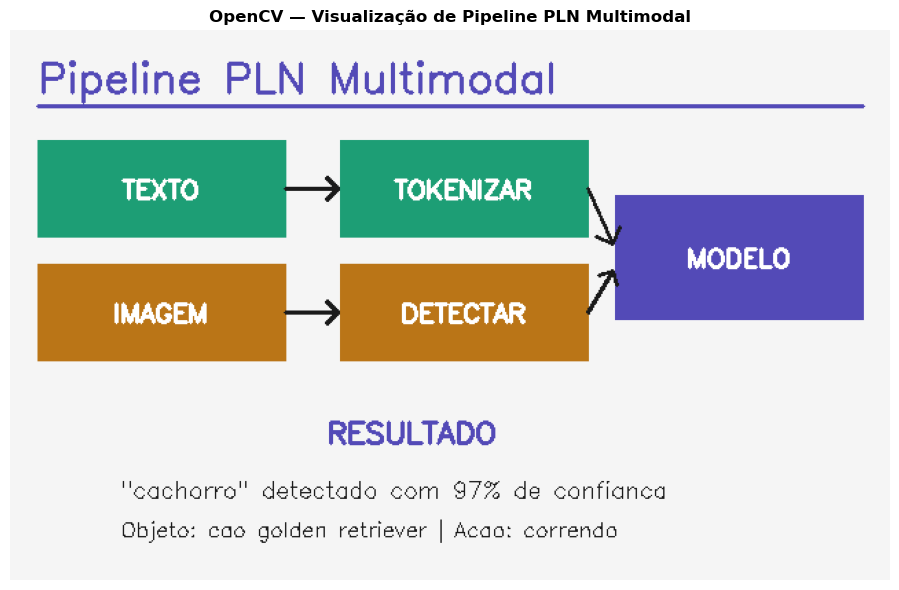

📐 Dimensões da imagem: (400, 640, 3)  (altura × largura × canais RGB)
💡 OpenCV usa BGR por padrão — sempre converter para RGB antes de exibir!


In [13]:
# ─────────────────────────────────────────────────────────────
# OPENcv — manipulação básica de imagens
# np.zeros() → cria imagem em branco
# cv2.putText() → escreve texto na imagem
# cv2.rectangle() → desenha retângulo
# ─────────────────────────────────────────────────────────────

# Criar uma imagem sintética para demonstração
# (640x400 pixels, 3 canais de cor RGB)
img = np.ones((400, 640, 3), dtype=np.uint8) * 245  # Fundo cinza claro

# Paleta de cores (BGR no OpenCV!)
PURPLE = (183, 74, 83)    # #534AB7 em BGR
TEAL   = (117, 158, 29)   # #1D9E75 em BGR
AMBER  = (23, 117, 186)   # #BA7517 em BGR
DARK   = (26, 26, 26)
WHITE  = (255, 255, 255)

# Título
cv2.putText(img, 'Pipeline PLN Multimodal', (20, 45),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, PURPLE, 2)
cv2.line(img, (20, 55), (620, 55), PURPLE, 2)

# Desenhar caixas representando etapas do pipeline
etapas = [
    ('TEXTO',    (20,  80),  (200, 150), TEAL),
    ('IMAGEM',   (20, 170),  (200, 240), AMBER),
    ('TOKENIZAR',(240, 80),  (420, 150), TEAL),
    ('DETECTAR', (240, 170), (420, 240), AMBER),
    ('MODELO',   (440, 120), (620, 210), PURPLE),
]

for label, pt1, pt2, cor in etapas:
    cv2.rectangle(img, pt1, pt2, cor, -1)   # -1 = preenchido
    cx = (pt1[0] + pt2[0]) // 2
    cy = (pt1[1] + pt2[1]) // 2
    # Centralizar texto
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.putText(img, label, (cx - tw//2, cy + th//2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, WHITE, 2)

# Setas conectando etapas
cv2.arrowedLine(img, (200, 115), (238, 115), DARK, 2, tipLength=0.3)
cv2.arrowedLine(img, (200, 205), (238, 205), DARK, 2, tipLength=0.3)
cv2.arrowedLine(img, (420, 115), (438, 155), DARK, 2, tipLength=0.3)
cv2.arrowedLine(img, (420, 205), (438, 175), DARK, 2, tipLength=0.3)

# Resultado
cv2.putText(img, 'RESULTADO', (230, 300),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, PURPLE, 2)
cv2.putText(img, '"cachorro" detectado com 97% de confianca', (80, 340),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, DARK, 1)
cv2.putText(img, 'Objeto: cao golden retriever | Acao: correndo', (80, 368),
            cv2.FONT_HERSHEY_SIMPLEX, 0.50, DARK, 1)

# Exibir com matplotlib (melhor que cv2.imshow() em notebooks)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV usa BGR → converter para RGB
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('OpenCV — Visualização de Pipeline PLN Multimodal', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'📐 Dimensões da imagem: {img.shape}  (altura × largura × canais RGB)')
print('💡 OpenCV usa BGR por padrão — sempre converter para RGB antes de exibir!')

---
### 📖 Exemplo 4.2 — Pré-processamento de Imagem para PLN

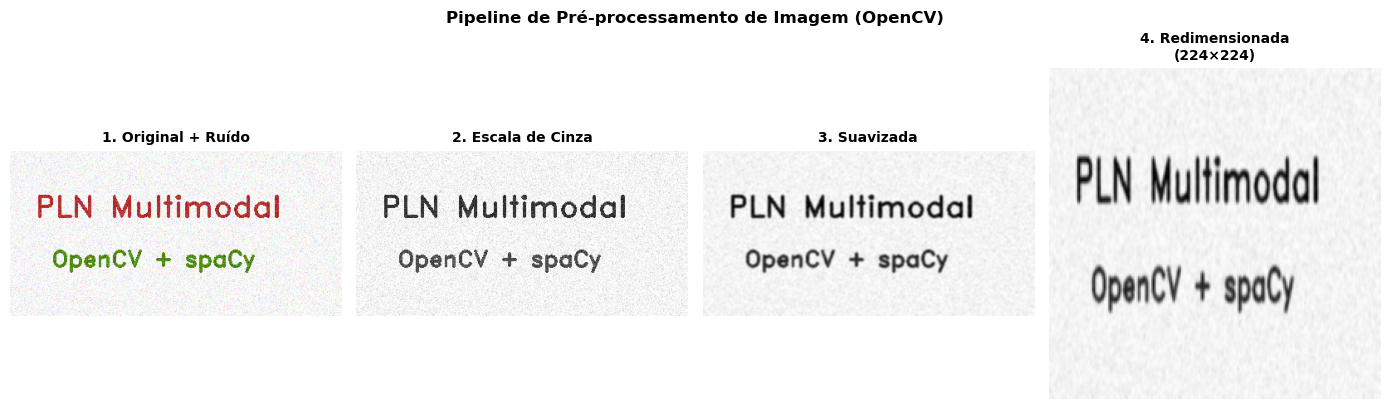

📊 Estatísticas após normalização:
   Mínimo: 0.3255  |  Máximo: 0.9922  |  Média: 0.9278
   Shape final: (224, 224)  (altura × largura)


In [14]:
# ─────────────────────────────────────────────────────────────
# PRÉ-PROCESSAMENTO DE IMAGENS
# Etapas comuns antes de enviar uma imagem para um modelo de PLN
#
# cv2.cvtColor()  → converter espaço de cores
# cv2.resize()    → redimensionar
# cv2.GaussianBlur() → suavizar (reduzir ruído)
# cv2.normalize() → normalizar valores de pixel
# ─────────────────────────────────────────────────────────────

# Criar imagem sintética com texto simulado
img_original = np.ones((200, 400, 3), dtype=np.uint8) * 255
cv2.putText(img_original, 'PLN Multimodal', (30, 80),
            cv2.FONT_HERSHEY_DUPLEX, 1.2, (50, 50, 180), 2)
cv2.putText(img_original, 'OpenCV + spaCy', (50, 140),
            cv2.FONT_HERSHEY_DUPLEX, 0.9, (20, 140, 80), 2)
# Adicionar ruído gaussiano
ruido = np.random.normal(0, 25, img_original.shape).astype(np.int16)
img_com_ruido = np.clip(img_original.astype(np.int16) + ruido, 0, 255).astype(np.uint8)

# ── Pipeline de pré-processamento
# 1. Converter para escala de cinza
img_cinza = cv2.cvtColor(img_com_ruido, cv2.COLOR_BGR2GRAY)

# 2. Suavizar com filtro Gaussiano (reduz ruído)
img_suave = cv2.GaussianBlur(img_cinza, (5, 5), 0)

# 3. Redimensionar para 224×224 (tamanho padrão de muitos modelos)
img_resize = cv2.resize(img_suave, (224, 224))

# 4. Normalizar pixels para [0, 1] (padrão para redes neurais)
img_norm = img_resize.astype(np.float32) / 255.0

# Exibir todas as etapas
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titulos = ['1. Original + Ruído', '2. Escala de Cinza', '3. Suavizada', '4. Redimensionada\n(224×224)']
imagens = [
    cv2.cvtColor(img_com_ruido, cv2.COLOR_BGR2RGB),
    img_cinza, img_suave, img_resize
]
cmaps = [None, 'gray', 'gray', 'gray']

for ax, img_show, titulo, cmap in zip(axes, imagens, titulos, cmaps):
    ax.imshow(img_show, cmap=cmap)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.axis('off')
    h, w = img_show.shape[:2]
    ax.set_xlabel(f'{w}×{h}px', fontsize=9)

plt.suptitle('Pipeline de Pré-processamento de Imagem (OpenCV)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'📊 Estatísticas após normalização:')
print(f'   Mínimo: {img_norm.min():.4f}  |  Máximo: {img_norm.max():.4f}  |  Média: {img_norm.mean():.4f}')
print(f'   Shape final: {img_norm.shape}  (altura × largura)')

---
# 🟣 PARTE 5 — TensorFlow / Keras
## Deep Learning para PLN

O **TensorFlow** é um framework de deep learning desenvolvido pelo Google.  
O **Keras** é sua API de alto nível — mais simples e didática.

Nesta aula, veremos apenas os fundamentos. As arquiteturas mais complexas  
(RNNs, LSTMs, Transformers) serão exploradas na Aula 3.

---
### 📖 Exemplo 5.1 — Vetorização de Texto com Keras

In [20]:
# ─────────────────────────────────────────────────────────────
# VETORIZAÇÃO DE TEXTO
# Redes neurais não entendem texto — precisamos converter
# palavras em números. Existem duas abordagens básicas:
#
# 1. Bag of Words (BoW) → conta ocorrências de palavras
# 2. Word Embeddings    → vetores densos com significado semântico
#
# TextVectorization → camada Keras para converter texto em vetores
# ─────────────────────────────────────────────────────────────

import tensorflow as tf
from tensorflow import keras

print(f'✅ TensorFlow: {tf.__version__}')
print()

# Corpus de treinamento
corpus = [
    "o gato subiu no telhado",
    "o cachorro latiu para o gato",
    "processamento de linguagem natural é fascinante",
    "redes neurais aprendem com dados de texto",
    "o modelo de linguagem processa texto",
]

# Criar a camada de vetorização
# output_mode='count' → conta ocorrências de cada palavra
vetorizador = keras.layers.TextVectorization(
    max_tokens=50,          # Vocabulário máximo de 50 palavras
    output_mode='count'     # Bag of Words: conta ocorrências
)

# Adaptar ao corpus (aprende o vocabulário)
vetorizador.adapt(corpus)

# Verificar o vocabulário aprendido
vocabulario = vetorizador.get_vocabulary()
print(f'📚 Vocabulário aprendido ({len(vocabulario)} palavras):')
print(f'   {vocabulario}\n')

# Vetorizar novas frases
frases_novas = [
    "o gato e o cachorro",
    "texto de linguagem natural"
]

vetores = vetorizador(frases_novas).numpy()

print('🔢 Vetores Bag-of-Words:')
for frase, vetor in zip(frases_novas, vetores):
    # Mostrar apenas posições não-zero
    nao_zeros = {vocabulario[i]: int(vetor[i]) for i in range(len(vetor)) if vetor[i] > 0}
    print(f'  "{frase}"')
    print(f'   → {nao_zeros}\n')

✅ TensorFlow: 2.15.0



📚 Vocabulário aprendido (23 palavras):
   ['[UNK]', 'o', 'de', 'texto', 'linguagem', 'gato', 'é', 'telhado', 'subiu', 'redes', 'processamento', 'processa', 'para', 'no', 'neurais', 'natural', 'modelo', 'latiu', 'fascinante', 'dados', 'com', 'cachorro', 'aprendem']

🔢 Vetores Bag-of-Words:
  "o gato e o cachorro"
   → {'[UNK]': 1, 'o': 2, 'gato': 1, 'cachorro': 1}

  "texto de linguagem natural"
   → {'de': 1, 'texto': 1, 'linguagem': 1, 'natural': 1}



---
### 📖 Exemplo 5.2 — Modelo Simples de Classificação de Texto

In [21]:
# ─────────────────────────────────────────────────────────────
# MODELO DE CLASSIFICAÇÃO DE TEXTO com Keras
# Vamos criar um modelo simples que aprende a classificar
# textos como POSITIVO ou NEGATIVO
#
# Sequential()  → modelo com camadas em sequência
# Embedding     → aprende vetores de palavras
# GlobalAveragePooling1D → agrega os vetores
# Dense         → camada totalmente conectada
# ─────────────────────────────────────────────────────────────

# Dataset de treino (textos e rótulos: 1=positivo, 0=negativo)
textos_treino = [
    "great movie loved it", "excellent performance amazing",
    "wonderful story beautiful film", "fantastic acting loved the plot",
    "best film ever seen brilliant", "outstanding cinematography loved",
    "terrible movie hated it", "awful performance very bad",
    "horrible story boring film", "dreadful acting hated the plot",
    "worst film ever seen terrible", "poor quality very disappointed",
]
rotulos_treino = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]

# Configurar vetorizador
VOCAB_SIZE  = 100
EMBED_DIM   = 16    # Dimensão dos word embeddings
MAX_LEN     = 10    # Comprimento máximo de sequência

vet = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN
)
vet.adapt(textos_treino)

# Construir o modelo
modelo = keras.Sequential([
    vet,                                                 # Texto → IDs
    keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),       # IDs → vetores
    keras.layers.GlobalAveragePooling1D(),               # Vetores → vetor único
    keras.layers.Dense(8, activation='relu'),            # Camada oculta
    keras.layers.Dense(1, activation='sigmoid')          # Saída: 0 a 1
])

# Compilar
modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🏗️ Arquitetura do modelo:')
modelo.summary()

# Treinar
print('\n🎓 Treinando o modelo...')
historico = modelo.fit(
    textos_treino,
    rotulos_treino,
    epochs=30,
    verbose=0   # Silencioso durante treino
)

acc_final = historico.history['accuracy'][-1]
print(f'   Acurácia final no treino: {acc_final:.2%}')

# Testar com novas frases
print('\n🔮 Testando com novas frases:')
frases_teste = [
    "loved this amazing film",
    "terrible and boring movie",
    "the film was great"
]

predicoes = modelo.predict(frases_teste, verbose=0)

for frase, pred in zip(frases_teste, predicoes):
    score = pred[0]
    sentimento = '😊 POSITIVO' if score > 0.5 else '😞 NEGATIVO'
    print(f'  "{frase}"')
    print(f'   → {sentimento} (score: {score:.4f})\n')


🏗️ Arquitetura do modelo:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_1 (Text  (None, 10)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 10, 16)            1600      
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 8)                 136       
                                                                 
 dense_1 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1745 (6.82 KB)


---
### 📖 Exemplo 5.3 — Visualizar Curva de Treinamento

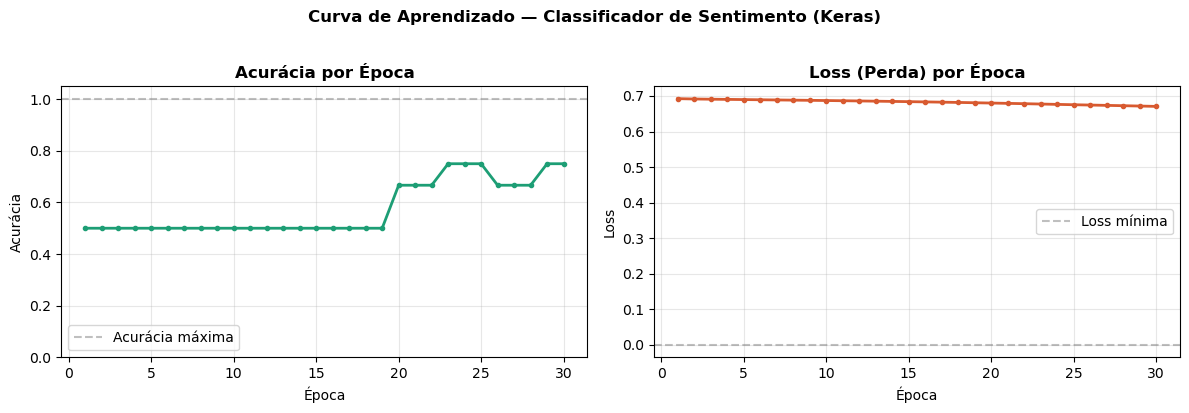

💡 Interpretação:
   Acurácia crescendo → modelo aprendendo
   Loss diminuindo   → erro diminuindo
   Se acurácia parar de crescer = modelo convergiu


In [22]:
# ─────────────────────────────────────────────────────────────
# CURVA DE APRENDIZADO
# Visualizar como o modelo evolui durante o treinamento
# é essencial para diagnosticar problemas (overfitting, etc.)
# ─────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epocas = range(1, len(historico.history['accuracy']) + 1)

# Acurácia
ax1.plot(epocas, historico.history['accuracy'],
         color='#1D9E75', linewidth=2, marker='o', markersize=3)
ax1.set_title('Acurácia por Época', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_ylim([0, 1.05])
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Acurácia máxima')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss (perda)
ax2.plot(epocas, historico.history['loss'],
         color='#D85A30', linewidth=2, marker='o', markersize=3)
ax2.set_title('Loss (Perda) por Época', fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Loss mínima')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Curva de Aprendizado — Classificador de Sentimento (Keras)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Interpretação:')
print('   Acurácia crescendo → modelo aprendendo')
print('   Loss diminuindo   → erro diminuindo')
print('   Se acurácia parar de crescer = modelo convergiu')

---
## ✏️ Exercícios

Resolva os exercícios abaixo nas células indicadas.

> 💡 **Dica:** Use os exemplos anteriores como referência.

### Exercício 1 — Pipeline NLTK Completo
Dado o texto abaixo, aplique o pipeline NLTK completo:
1. Tokenize por palavras
2. Converta para minúsculas
3. Remova stopwords em Português
4. Aplique stemming
5. Exiba os 10 tokens mais frequentes após o processamento

```python
texto_exercicio = """
A inteligência artificial revolucionou a forma como as empresas processam dados.
Algoritmos de aprendizado de máquina analisam grandes volumes de informações.
O processamento de linguagem natural permite que computadores leiam e entendam texto humano.
Empresas de tecnologia investem bilhões em pesquisas de inteligência artificial.
"""
```

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 1

texto_exercicio = """
A inteligência artificial revolucionou a forma como as empresas processam dados.
Algoritmos de aprendizado de máquina analisam grandes volumes de informações.
O processamento de linguagem natural permite que computadores leiam e entendam texto humano.
Empresas de tecnologia investem bilhões em pesquisas de inteligência artificial.
"""


### Exercício 2 — spaCy: Análise Completa
Use o spaCy para analisar a frase abaixo e:
1. Exiba todos os tokens com seu **POS tag** e **lema**
2. Liste todas as **entidades nomeadas** encontradas
3. Filtre e exiba apenas os **substantivos e nomes próprios**

```
"A Microsoft anunciou que o CEO Satya Nadella investirá 10 bilhões de dólares em IA em 2025."
```

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 2

frase_ex2 = "A Microsoft anunciou que o CEO Satya Nadella investirá 10 bilhões de dólares em IA em 2025."


### Exercício 3 — Hugging Face: Múltiplas Tarefas
Use pipelines do Hugging Face para:
1. Classificar o sentimento de 3 frases à sua escolha
2. Classificar uma notícia em categorias usando zero-shot:
   - Categorias: `['tecnologia', 'esporte', 'política', 'saúde', 'entretenimento']`
3. Exibir os resultados de forma clara e formatada

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 3

# Dica: reutilize os pipelines já carregados: analisador e classificador


### Exercício 4 — Desafio: Pipeline Integrado
Crie um pipeline que integre **NLTK + spaCy + Hugging Face**:
1. Receba um texto em inglês
2. Use NLTK para tokenizar e remover stopwords
3. Use spaCy para extrair entidades (NER)
4. Use Hugging Face para classificar o sentimento
5. Exiba um relatório completo da análise

```
texto = "Apple CEO Tim Cook announced record profits in Q4 2024. \
         Investors are very excited about the company's future growth plans."
```

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 4

texto_desafio = ("Apple CEO Tim Cook announced record profits in Q4 2024. "
                 "Investors are very excited about the company's future growth plans.")


---
## ✅ Resolução dos Exercícios

In [ ]:
# ── RESOLUÇÃO: Exercício 1 — Pipeline NLTK Completo

from nltk.stem import RSLPStemmer
from nltk.probability import FreqDist

texto_exercicio = """
A inteligência artificial revolucionou a forma como as empresas processam dados.
Algoritmos de aprendizado de máquina analisam grandes volumes de informações.
O processamento de linguagem natural permite que computadores leiam e entendam texto humano.
Empresas de tecnologia investem bilhões em pesquisas de inteligência artificial.
"""

stemmer = RSLPStemmer()
stop_pt = set(stopwords.words('portuguese'))

# 1. Tokenizar
tokens = word_tokenize(texto_exercicio, language='portuguese')
# 2. Minúsculas
tokens = [t.lower() for t in tokens]
# 3. Remover stopwords e pontuação
tokens = [t for t in tokens if t.isalpha() and t not in stop_pt]
# 4. Stemming
tokens_stem = [stemmer.stem(t) for t in tokens]

freq = FreqDist(tokens_stem)

print('📊 Pipeline NLTK Completo — Top 10 tokens:')
print(f'  {"#":<4} {"Stem":<20} {"Frequência":<10} {"Gráfico"}')
print('  ' + '-' * 50)
for i, (token, n) in enumerate(freq.most_common(10)):
    barra = '█' * (n * 3)
    print(f'  {i+1:<4} {token:<20} {n:<10} {barra}')

In [ ]:
# ── RESOLUÇÃO: Exercício 2 — spaCy: Análise Completa

frase_ex2 = "A Microsoft anunciou que o CEO Satya Nadella investirá 10 bilhões de dólares em IA em 2025."
doc_ex2 = nlp_pt(frase_ex2)

print(f'📝 Frase: "{frase_ex2}"\n')

# 1. Tokens com POS e lema
print('1️⃣ Tokens com POS Tag e Lema:')
print(f'  {"Token":<18} {"POS":<10} {"Lema"}')
print('  ' + '-' * 42)
for token in doc_ex2:
    if not token.is_punct:
        print(f'  {token.text:<18} {token.pos_:<10} {token.lemma_}')

# 2. Entidades
print(f'\n2️⃣ Entidades Nomeadas:')
if doc_ex2.ents:
    for ent in doc_ex2.ents:
        print(f'  → "{ent.text}" → {ent.label_}')
else:
    print('  (modelo sm tem NER limitada — use modelo md/lg para melhores resultados)')

# 3. Apenas substantivos e nomes próprios
print(f'\n3️⃣ Substantivos e Nomes Próprios:')
for token in doc_ex2:
    if token.pos_ in ('NOUN', 'PROPN'):
        print(f'  → "{token.text}" ({token.pos_})')

In [ ]:
# ── RESOLUÇÃO: Exercício 3 — Hugging Face: Múltiplas Tarefas

# 1. Sentimento
frases_sentimento = [
    "I love learning new programming tools!",
    "This error is driving me crazy.",
    "The documentation is acceptable."
]

print('😊 1. Análise de Sentimento:')
print(f'  {"Frase":<45} {"Sentimento":<12} {"Confiança"}')
print('  ' + '-' * 68)
for frase, res in zip(frases_sentimento, analisador(frases_sentimento)):
    emoji = '😊' if res['label'] == 'POSITIVE' else '😞'
    print(f'  {frase:<45} {emoji} {res["label"]:<10} {res["score"]:.2%}')

# 2. Zero-shot
noticia = "Scientists develop new vaccine that reduces cancer risk by 40% in clinical trials."
categorias = ['tecnologia', 'esporte', 'política', 'saúde', 'entretenimento']
res_zs = classificador(noticia, candidate_labels=categorias)

print(f'\n🎯 2. Classificação Zero-Shot:')
print(f'   Notícia: "{noticia}"\n')
for label, score in zip(res_zs['labels'], res_zs['scores']):
    barra = '█' * int(score * 25) + '░' * (25 - int(score * 25))
    destaque = '⭐' if label == res_zs['labels'][0] else '  '
    print(f'   {destaque} {label:<16} {score:.2%}  {barra}')

In [ ]:
# ── RESOLUÇÃO: Exercício 4 — Pipeline Integrado

texto_desafio = ("Apple CEO Tim Cook announced record profits in Q4 2024. "
                 "Investors are very excited about the company's future growth plans.")

print('=' * 60)
print('  📋 RELATÓRIO DE ANÁLISE PLN INTEGRADO')
print('=' * 60)
print(f'\n📄 Texto: "{texto_desafio}"\n')

# ── NLTK: tokenização e stopwords
stop_en = set(stopwords.words('english'))
tokens_brutos = word_tokenize(texto_desafio.lower())
tokens_relevantes = [t for t in tokens_brutos if t.isalpha() and t not in stop_en]

print(f'1️⃣  NLTK — Tokens relevantes ({len(tokens_relevantes)}):')
print(f'   {tokens_relevantes}\n')

# ── spaCy: NER
doc_integrado = nlp_en(texto_desafio)
print('2️⃣  spaCy — Entidades Nomeadas:')
entidades_vistas = set()
for ent in doc_integrado.ents:
    if ent.text not in entidades_vistas:
        print(f'   → "{ent.text}" [{ent.label_}]')
        entidades_vistas.add(ent.text)

# ── Hugging Face: Sentimento
resultado_hf = analisador(texto_desafio)[0]
emoji = '😊' if resultado_hf['label'] == 'POSITIVE' else '😞'
print(f'\n3️⃣  Hugging Face — Sentimento:')
print(f'   {emoji} {resultado_hf["label"]} (confiança: {resultado_hf["score"]:.2%})')

print('\n' + '=' * 60)

---
## 📝 Resumo da Aula

| Ferramenta | Instalação | Melhor uso | Limitação |
|---|---|---|---|
| **NLTK** | `pip install nltk` | Aprendizado, corpora | Lento para produção |
| **spaCy** | `pip install spacy` | Pipelines rápidos e NER | Menos flexível para fine-tuning |
| **Hugging Face** | `pip install transformers` | Modelos modernos | Modelos pesados |
| **OpenCV** | `pip install opencv-python` | Visão + texto | Foco em imagens |
| **TensorFlow** | `pip install tensorflow` | Treinar modelos próprios | Curva de aprendizado |

---

## 🔜 Próxima Aula

**Aula 3 — Arquiteturas para PLN**  
Como RNNs, LSTMs, GRUs e Transformers funcionam internamente —  
e por que o mecanismo de atenção revolucionou o PLN moderno.